# CakapKarier AI - Career Match Experiment

Notebook ini mendokumentasikan pekerjaan AI Engineer untuk sistem **career readiness and job matching** CakapKarier AI. Fokusnya adalah menyiapkan dataset final dari tim Data Science, membangun model Deep Learning TensorFlow, mengevaluasi performa, mengekspor artefak siap produksi, dan menyediakan contoh inference/API yang dapat diintegrasikan oleh tim fullstack.

Seluruh logic utama tetap berada di modul Python (`pipelines/` dan `services/career-match/`) agar reproducible, mudah dites, dan dapat dipakai langsung oleh backend. Notebook ini berfungsi sebagai laporan eksperimen, dokumentasi teknis, dan bahan demo untuk menjelaskan alur AI Engine.

Ruang lingkup notebook:

- Validasi input dataset final Data Science dan data dictionary.
- Preprocessing lanjutan untuk kebutuhan model: extraction skill, pengalaman, pendidikan, sertifikasi, work mode, dan role family.
- Pembuatan pasangan training `match` dan `not_match` menggunakan weak supervision.
- Training model Deep Learning berbasis TensorFlow Functional API.
- Evaluasi metrik, classification report, confusion matrix, durasi epoch, dan TensorBoard log.
- Export model `.keras`, SavedModel, katalog lowongan, dan kontrak API.
- Simulasi inference untuk kebutuhan integrasi aplikasi web.


## 1. Setup Path dan Konfigurasi

Bagian ini menyiapkan path project dan import dependency supaya notebook bisa dijalankan secara konsisten dari beberapa lokasi kerja: root repository, folder `AIEngine`, atau langsung dari folder `notebooks`.

Hal yang dilakukan pada cell setup:

- Mendeteksi lokasi `AIEngine` secara otomatis.
- Menambahkan folder service `career-match/src` ke `sys.path` agar modul inference dapat di-import.
- Menentukan lokasi dataset final Data Science: `data/raw/all_data_clean.csv`.
- Menentukan lokasi data dictionary DS: `data/raw/Data_Dictionary.xlsx`.
- Menentukan folder processed dataset dan model registry.
- Mengatur opsi `RUN_PREPROCESSING` dan `RUN_TRAINING` agar eksperimen bisa dijalankan ulang jika diperlukan.
- Mengatur style visualisasi Matplotlib yang dipakai di seluruh notebook.


In [21]:
from pathlib import Path
import importlib
import json
import sys
from textwrap import wrap

from IPython.display import Image as IPImage, display as ipy_display
import pandas as pd
import matplotlib.pyplot as plt


def find_ai_engine_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if path.name == 'AIEngine' and (path / 'pipelines').exists():
            return path
        candidate = path / 'AIEngine'
        if (candidate / 'pipelines').exists():
            return candidate
    raise RuntimeError('Folder AIEngine tidak ditemukan dari current working directory.')


AIENGINE_ROOT = find_ai_engine_root(Path.cwd())
REPO_ROOT = AIENGINE_ROOT.parent
SERVICE_SRC = AIENGINE_ROOT / 'services' / 'career-match' / 'src'

for path in [AIENGINE_ROOT, SERVICE_SRC]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

importlib.invalidate_caches()

DS_CLEAN_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'all_data_clean.csv'
DS_DICTIONARY_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'Data_Dictionary.xlsx'
RAW_PATHS = [DS_CLEAN_PATH] if DS_CLEAN_PATH.exists() else []
PROCESSED_DIR = AIENGINE_ROOT / 'data' / 'processed' / 'career-match-v1'
MODEL_DIR = AIENGINE_ROOT / 'models' / 'registry' / 'career-match' / 'v1'

# Ubah menjadi True jika ingin menjalankan ulang dari awal.
RUN_PREPROCESSING = False
RUN_TRAINING = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'


def show_figure(fig, output_path=None, width=None, dpi=180):
    # Render figure secara stabil di VS Code/Jupyter meski backend Matplotlib non-interactive.
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
        ipy_display(IPImage(filename=str(output_path), width=width))
    else:
        ipy_display(fig)
    plt.close(fig)


def plot_barh(series, title, xlabel='Count', color='#2563eb'):
    fig, ax = plt.subplots(figsize=(10, 5))
    series.sort_values().plot(kind='barh', color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.tight_layout()
    show_figure(fig)

print('AIENGINE_ROOT =', AIENGINE_ROOT)
print('RAW_PATHS =', RAW_PATHS)
print('MODEL_DIR exists =', MODEL_DIR.exists())



AIENGINE_ROOT = C:\DBS Foundation\CakapKarier AI\AIEngine
RAW_PATHS = [WindowsPath('C:/DBS Foundation/CakapKarier AI/AIEngine/data/raw/all_data_clean.csv')]
MODEL_DIR exists = True


## 2. Business Objective

Project CakapKarier AI membutuhkan model untuk membantu pengguna memahami kesiapan kerja, role yang paling relevan, skill gap, dan rekomendasi pengembangan skill. Karena dataset yang tersedia berisi lowongan kerja, model dibangun sebagai career matching model: kandidat dibandingkan terhadap katalog lowongan, lalu sistem mengembalikan readiness score dan rekomendasi role terbaik.

Checklist yang dipenuhi:

- TensorFlow Functional API
- Custom Layer: `CosineSimilarityLayer`, `AbsoluteDifferenceLayer`
- Custom Loss Function: `CareerMatchLoss`
- Custom Callback: `QualityThresholdCallback`
- Custom training loop dengan `tf.GradientTape`
- Export `.keras` dan SavedModel
- Inference code dan FastAPI service
- TensorBoard log
- Optional GenAI summary fallback

## 3. Raw Dataset Assessment

Bagian ini memvalidasi dataset final dari tim Data Science sebelum dipakai oleh pipeline AI. Dataset yang dipakai adalah `all_data_clean.csv` dan data dictionary pendukung `Data_Dictionary.xlsx`.

Tahap ini bukan untuk mengulang cleaning data mentah, tetapi untuk memastikan data final sudah dapat digunakan oleh model. Validasi yang dilakukan meliputi:

- **Struktur kolom**: memastikan kolom penting seperti `job_title`, `company`, `location`, `description`, `requirements`, dan `skills_text` tersedia.
- **Jumlah data dan sumber data**: melihat total baris dan distribusi sumber data, misalnya Glints dan LinkedIn.
- **Missing value**: mengecek apakah ada kolom penting yang kosong dan berpotensi mengganggu feature extraction.
- **Duplikasi**: memeriksa kemungkinan duplikasi berdasarkan `job_detail` atau informasi lowongan.
- **Distribusi awal**: melihat job title, lokasi, dan panjang teks agar AI Engineer memahami karakteristik data sebelum training.

Output dari tahap ini menjadi dasar keputusan apakah dataset sudah cukup stabil untuk diproses menjadi training-ready dataset. Jika ditemukan masalah besar, catatan ini dapat dikembalikan ke tim Data Science untuk diperbaiki di dataset final.


In [22]:

importlib.invalidate_caches()
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')
preprocess_module = importlib.reload(preprocess_module)
raw_df = preprocess_module.load_raw_sources(RAW_PATHS)

raw_summary = {
    'rows': len(raw_df),
    'columns': list(raw_df.columns),
    'source_distribution': raw_df['source'].value_counts().to_dict() if 'source' in raw_df.columns else {},
    'missing_values': raw_df.isna().sum().to_dict(),
    'duplicate_job_detail': int(raw_df.duplicated('job_detail').sum()) if 'job_detail' in raw_df else None,
    'unique_job_titles': int(raw_df['job_title'].nunique()) if 'job_title' in raw_df else None,
}
raw_summary


{'rows': 2209,
 'columns': ['source',
  'source_sheet',
  'source_row_id',
  'job_title',
  'company',
  'location',
  'job_detail',
  'description',
  'requirements',
  'skills_text',
  'skills_clean_text',
  'job_benefits'],
 'source_distribution': {'glints': 1980, 'linkedin': 229},
 'missing_values': {'source': 0,
  'source_sheet': 0,
  'source_row_id': 0,
  'job_title': 0,
  'company': 0,
  'location': 0,
  'job_detail': 0,
  'description': 0,
  'requirements': 0,
  'skills_text': 0,
  'skills_clean_text': 0,
  'job_benefits': 0},
 'duplicate_job_detail': 228,
 'unique_job_titles': 1331}

In [23]:
if DS_DICTIONARY_PATH.exists():
    ds_dictionary = pd.read_excel(DS_DICTIONARY_PATH)
    display(ds_dictionary)
else:
    print('Data dictionary DS belum tersedia di AIEngine/data/raw/Data_Dictionary.xlsx')


,No,Column,Data Type,Deskripsi
0,1,web_scraper_order,Object/String,ID urutan hasil scraping untuk setiap data low...
1,2,web_scraper_start_url,Object/String,URL awal halaman scraping yang digunakan untuk...
2,3,job_title,Object/String,Nama posisi pekerjaan yang ditawarkan.
3,4,company,Object/String,Nama perusahaan yang membuka lowongan kerja.
4,5,location,Object/String,Lokasi perusahaan atau lokasi pekerjaan tersedia.
5,6,job_detail,Object/String,URL detail lowongan pekerjaan yang mengarah ke...
6,7,description,Object/String,"Deskripsi umum mengenai pekerjaan, tanggung ja..."
7,8,requirements,Object/String,Kualifikasi atau syarat yang dibutuhkan (Pendi...
8,9,skills,Object/String,Daftar skill atau kemampuan yang dibutuhkan da...
9,10,job_benefits,Object/String,Informasi benefit atau keuntungan yang diberik...


,source,source_sheet,job_title,company,location,requirements,skills_text
0,glints,,Technical Support Intern,Wirakom Sistem,"Tangerang Selatan, Banten",Job RequirementsOn-site1 - 3 years of experien...,SkillsTechnical SupportIT SupportNetwork Troub...
1,glints,,Mandarin Secretary,Pt. Sentum Teknologi Indonesia,"Jakarta Utara, Dki Jakarta",Job RequirementsOn-site1 - 3 years of experien...,SkillsCommunication SkillsMicrosoft OfficeAdmi...
2,glints,,Sales Manager,Pt United Teknologi Integrasi,"Jakarta Pusat, Dki Jakarta",Job RequirementsOn-site3 - 5 years of experien...,SkillsGive it a try! - 1 of 12 skills match yo...
3,glints,,Project Manager,Bisnis Adviz Solusi,"Jakarta Pusat, Dki Jakarta",Job RequirementsOn-site3 - 5 years of experien...,SkillsProject ManagementRisk ManagementTeam Ma...
4,glints,,"Software Developer (Java Springboot, Golang, R...",Pt Sigma Global Teknologi,"Jakarta Selatan, Dki Jakarta",Job RequirementsOn-site5 - 10 years of experie...,SkillsSpringbootCore JavaSoftware DevelopmentJ...


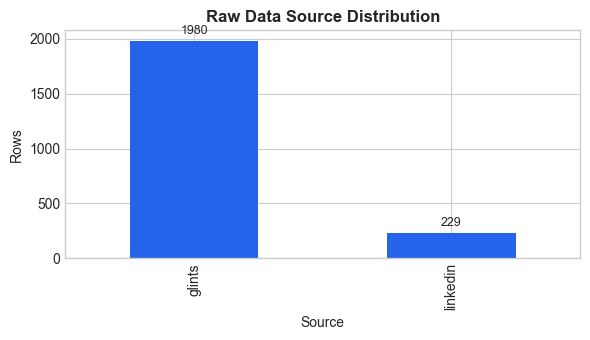

,count
job_title,
It Support,42
It Project Manager,34
System Analyst,30
It Business Analyst,29
Data Engineer,25
Technical Writer,17
It Sales Executive,17
Staff It,17
Software Developer,16


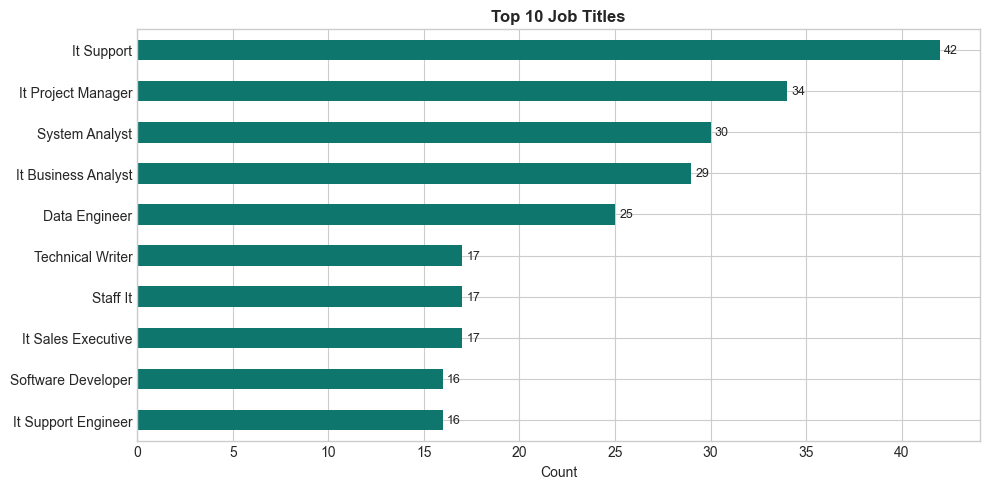

,count
location,
"Jakarta Selatan, Dki Jakarta",572
"Jakarta Pusat, Dki Jakarta",170
"Jakarta Barat, Dki Jakarta",137
"Surabaya, Jawa Timur",132
"Jakarta Utara, Dki Jakarta",102
"Tangerang, Banten",77
"Tangerang Selatan, Banten",67
"Bandung, Jawa Barat",61
"Jakarta Timur, Dki Jakarta",59


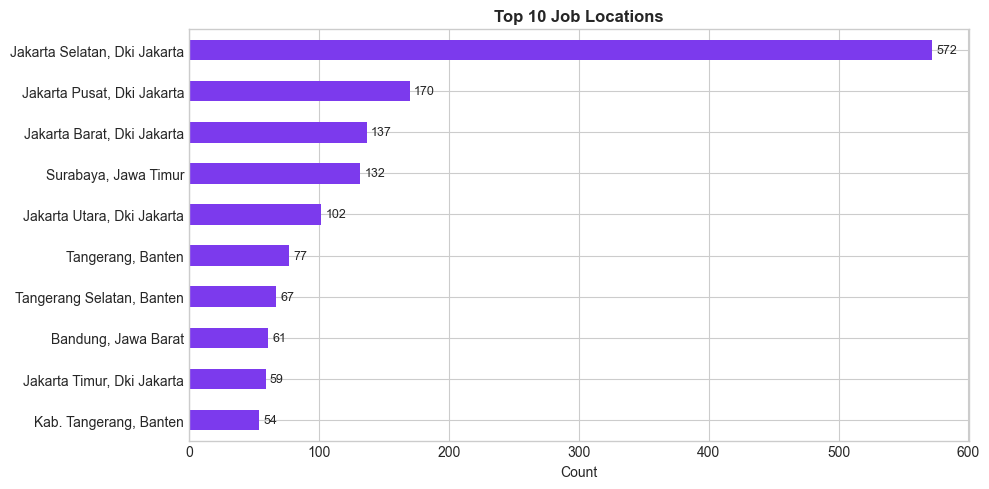

Tidak ada missing value pada dataset raw.


In [24]:
preview_cols = [
    col for col in [
        'source',
        'source_sheet',
        'job_title',
        'company',
        'location',
        'requirements',
        'skills_text',
    ]
    if col in raw_df.columns
]
display(raw_df[preview_cols].head(5))

fig, ax = plt.subplots(figsize=(6, 3.5))
raw_df['source'].value_counts().plot(kind='bar', ax=ax, color='#2563eb')
ax.set_title('Raw Data Source Distribution')
ax.set_xlabel('Source')
ax.set_ylabel('Rows')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
show_figure(fig)

top_titles = raw_df['job_title'].value_counts().head(10)
top_locations = raw_df['location'].value_counts().head(10)
missing_values = raw_df.isna().sum().sort_values(ascending=False)

display(top_titles.rename('count').to_frame())
plot_barh(top_titles, 'Top 10 Job Titles', color='#0f766e')

display(top_locations.rename('count').to_frame())
plot_barh(top_locations, 'Top 10 Job Locations', color='#7c3aed')

non_zero_missing = missing_values[missing_values > 0]
if len(non_zero_missing):
    display(non_zero_missing.rename('missing_count').to_frame())
    plot_barh(non_zero_missing, 'Missing Values by Column', color='#dc2626')
else:
    print('Tidak ada missing value pada dataset raw.')



,description_words,requirements_words,skills_chars
count,2209.00,2209.00,2209.00
mean,152.42,8.66,119.12
std,130.29,3.21,85.47
min,1.00,0.00,0.00
25%,71.00,9.00,63.00
50%,130.00,9.00,100.00
75%,208.00,11.00,146.00
max,1106.00,13.00,893.00


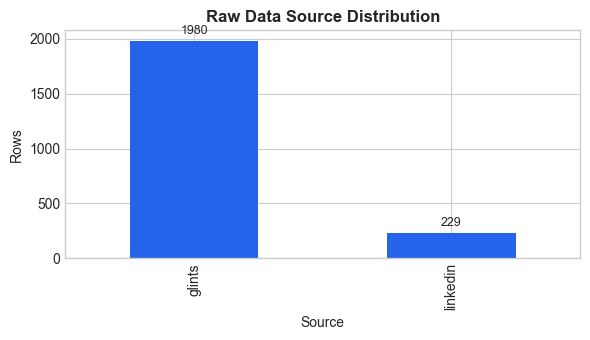

In [25]:
skills_column = 'skills_text' if 'skills_text' in raw_df.columns else None
text_length_df = pd.DataFrame({
    'description_words': raw_df['description'].fillna('').astype(str).str.split().str.len(),
    'requirements_words': raw_df['requirements'].fillna('').astype(str).str.split().str.len(),
    'skills_chars': raw_df[skills_column].fillna('').astype(str).str.len() if skills_column else 0,
})

display(text_length_df.describe().round(2))

axes = text_length_df[['description_words', 'requirements_words']].hist(
    bins=30,
    figsize=(12, 4),
    color='#2563eb',
    edgecolor='white',
)
for ax in axes.flatten():
    ax.set_title(ax.get_title().replace('_', ' ').title())
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Job Count')
plt.tight_layout()
show_figure(fig)



## 4. Preprocessing dan Weak Supervision

Bagian ini adalah **model-specific preprocessing**, bukan cleaning ulang dari data mentah. Dataset sudah dibersihkan oleh tim Data Science, lalu AI Engineer mengubah dataset tersebut menjadi format yang dibutuhkan oleh model TensorFlow.

Tahap preprocessing di sisi AI dilakukan karena model tidak bisa langsung menerima tabel lowongan mentah sebagai input training. Model membutuhkan representasi teks, fitur numerik, label, dan pembagian data yang konsisten.

Proses yang dilakukan:

- **Schema normalization**: menyamakan nama dan format kolom agar pipeline bisa membaca data secara konsisten.
- **Text preparation**: menggabungkan informasi lowongan seperti job title, description, requirements, dan skills menjadi `job_text`.
- **Feature extraction**: mengekstrak skill, pengalaman, pendidikan, sertifikasi, work mode, seniority, dan role family dari data lowongan.
- **Numeric feature engineering**: membuat fitur seperti `skill_overlap`, `certification_overlap`, `experience_ratio`, `education_match`, `skill_count_ratio`, `missing_skill_ratio`, dan `seniority_gap`.
- **Synthetic candidate generation**: membuat profil kandidat sintetis dari karakteristik lowongan untuk kebutuhan training awal.
- **Weak supervision labeling**: membuat label `match` dan `not_match` secara otomatis karena dataset lowongan tidak memiliki label kandidat nyata.
- **Train/validation/test split**: membagi pasangan data agar evaluasi model tetap terpisah dari data training.
- **Export processed dataset**: menyimpan hasil preprocessing ke folder `data/processed/career-match-v1` agar training dapat direproduksi.

Strategi label weak supervision:

- **Positive pair**: kandidat sintetis dibuat memenuhi skill, pengalaman, pendidikan, atau karakteristik lowongan sehingga diberi label `match`.
- **Negative pair**: kandidat dibuat berasal dari role family berbeda atau sengaja dibuat underqualified sehingga diberi label `not_match`.

Strategi ini cukup untuk MVP karena belum tersedia data historis kandidat nyata. Untuk versi production, model sebaiknya dilatih ulang menggunakan data interaksi pengguna, hasil lamaran, feedback career coach, atau label manual dari domain expert.


In [26]:

importlib.invalidate_caches()
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')
preprocess_module = importlib.reload(preprocess_module)

if RUN_PREPROCESSING or not (PROCESSED_DIR / 'metadata.json').exists():
    preprocess_metadata = preprocess_module.run(
        raw_paths=RAW_PATHS,
        output_dir=PROCESSED_DIR,
        seed=42,
        negatives_per_job=2,
    )
else:
    preprocess_metadata = json.loads((PROCESSED_DIR / 'metadata.json').read_text(encoding='utf-8'))

preprocess_metadata


{'business_questions': ['Role pekerjaan IT apa yang paling sering muncul dari sumber Glints dan LinkedIn?',
  'Skill apa yang paling banyak diminta oleh pasar kerja?',
  'Bagaimana distribusi pengalaman minimum, work mode, dan lokasi lowongan?',
  'Seberapa siap profil kandidat terhadap lowongan berdasarkan skill, pengalaman, dan sertifikasi?'],
 'raw_sources': ['C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\data\\raw\\all_data_clean.csv'],
 'source_distribution': {'glints': 1980, 'linkedin': 229},
 'source_rows': 2209,
 'unique_job_titles': 1330,
 'pair_counts': {'train': 4635, 'val': 996, 'test': 996},
 'role_family_distribution': {'it-support-network': 499,
  'software-engineering': 365,
  'other-it': 333,
  'qa-security': 310,
  'data-ai': 258,
  'sales-account': 223,
  'product-project-business': 101,
  'admin-operations': 90,
  'design-content': 30},
 'work_mode_distribution': {'unknown': 1958,
  'onsite': 122,
  'remote': 96,
  'hybrid': 33},
 'top_locations': {'Jakarta Selatan,

,split,rows
0,jobs,2209
1,train_pairs,4635
2,val_pairs,996
3,test_pairs,996


,count
role_family,
it-support-network,499
software-engineering,365
other-it,333
qa-security,310
data-ai,258
sales-account,223
product-project-business,101
admin-operations,90
design-content,30


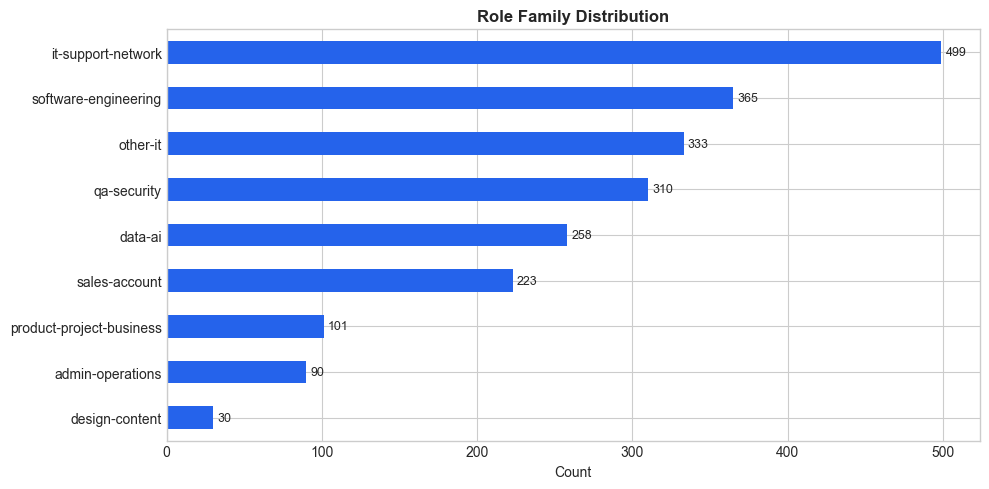

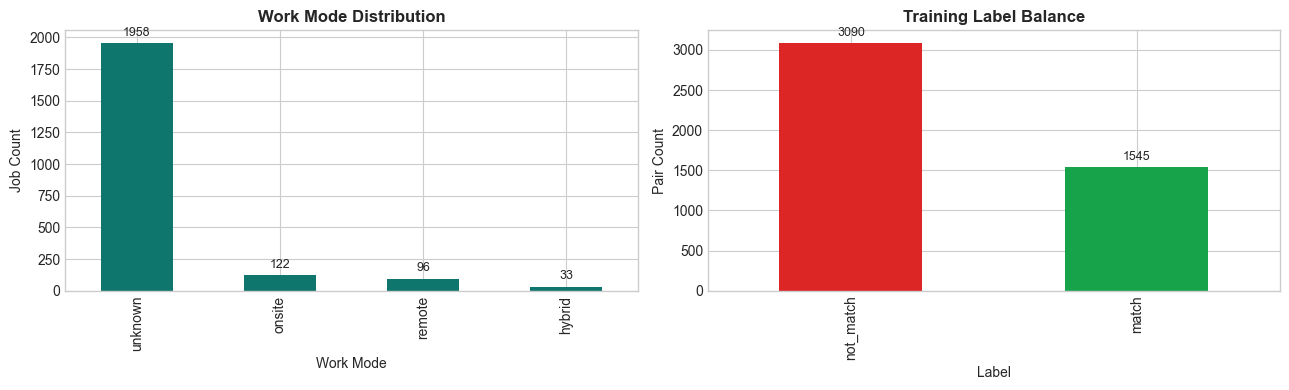

,pair_type,label,count
0,positive_market_fit,1.0,1545
1,negative_underqualified,0.0,1545
2,negative_cross_role,0.0,1545


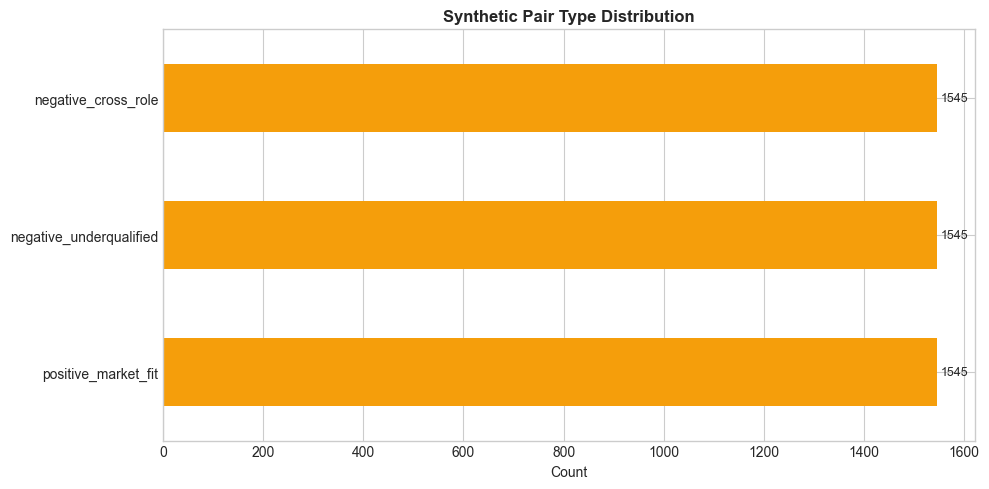

In [27]:
jobs_df = pd.read_csv(PROCESSED_DIR / 'jobs_processed.csv')
train_pairs = pd.read_csv(PROCESSED_DIR / 'train_pairs.csv')
val_pairs = pd.read_csv(PROCESSED_DIR / 'val_pairs.csv')
test_pairs = pd.read_csv(PROCESSED_DIR / 'test_pairs.csv')

processed_summary = pd.DataFrame(
    [
        {'split': 'jobs', 'rows': len(jobs_df)},
        {'split': 'train_pairs', 'rows': len(train_pairs)},
        {'split': 'val_pairs', 'rows': len(val_pairs)},
        {'split': 'test_pairs', 'rows': len(test_pairs)},
    ]
)
display(processed_summary)

role_counts = jobs_df['role_family'].value_counts()
work_mode_counts = jobs_df['work_mode'].value_counts()
pair_type_counts = train_pairs['pair_type'].value_counts()
label_counts = train_pairs['label'].map({0.0: 'not_match', 1.0: 'match'}).value_counts()

display(role_counts.rename('count').to_frame())
plot_barh(role_counts, 'Role Family Distribution', color='#2563eb')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
work_mode_counts.plot(kind='bar', ax=axes[0], color='#0f766e')
axes[0].set_title('Work Mode Distribution')
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Job Count')
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)

label_counts.plot(kind='bar', ax=axes[1], color=['#dc2626', '#16a34a'])
axes[1].set_title('Training Label Balance')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Pair Count')
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
plt.tight_layout()
show_figure(fig)

display(train_pairs[['pair_type', 'label']].value_counts().rename('count').reset_index())
plot_barh(pair_type_counts, 'Synthetic Pair Type Distribution', color='#f59e0b')


,count
communication,469
sql,376
it support,363
python,334
testing,288
technical support,284
troubleshooting,272
cloud,268
network troubleshooting,254
communication skills,250


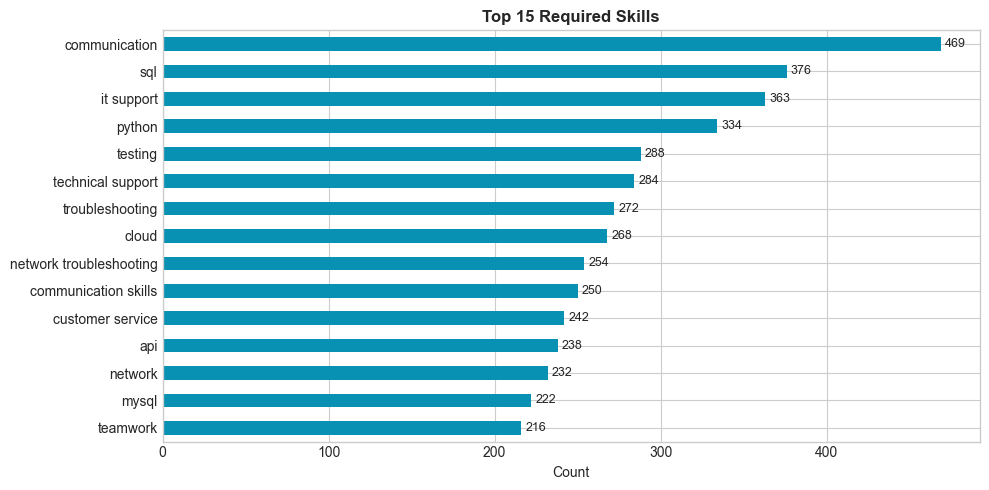

In [28]:
from collections import Counter

skill_counter = Counter()
for value in jobs_df['skills']:
    try:
        skills = json.loads(value) if isinstance(value, str) else value
    except json.JSONDecodeError:
        skills = []
    skill_counter.update(skills)

top_skills = pd.Series(dict(skill_counter.most_common(15)))
display(top_skills.rename('count').to_frame())
plot_barh(top_skills, 'Top 15 Required Skills', color='#0891b2')

## 5. Model Architecture

Model yang digunakan adalah **Deep Learning berbasis ANN dengan pola Siamese/Dual Encoder Matching**. Model ini bukan CNN, RNN, LSTM, GRU, atau Transformer, karena masalah bisnisnya bukan klasifikasi gambar atau prediksi urutan panjang, melainkan **membandingkan dua entitas teks**: profil kandidat dan kebutuhan lowongan kerja.

Arsitektur dibuat memakai **TensorFlow Functional API** karena model memiliki lebih dari satu input: `candidate_text`, `job_text`, dan `numeric_features`. Functional API membuat hubungan antar-input terlihat jelas, mudah diekspor ke format produksi, dan tetap kompatibel dengan custom layer.

### Alur Utama Model

1. **Candidate Profile**
   Bagian ini menerima informasi dari pengguna aplikasi, yaitu skill, pengalaman, pendidikan, sertifikasi, minat/bakat, dan target role. Data tersebut dinormalisasi menjadi `candidate_text` agar bisa diproses oleh encoder teks.

2. **Job Catalog Text**
   Bagian ini berasal dari dataset lowongan kerja final Data Science. Informasi seperti job title, description, requirements, dan required skills digabung menjadi `job_text`. Setiap kandidat akan dibandingkan dengan banyak lowongan dari katalog ini.

3. **Shared Text Encoder**
   `candidate_text` dan `job_text` masuk ke encoder yang sama. Encoder ini berisi `TextVectorization`, `Embedding`, dan `GlobalAveragePooling1D`. Karena bobot encoder dipakai bersama, embedding kandidat dan embedding lowongan berada di ruang representasi yang sama sehingga bisa dibandingkan secara adil.

4. **Pairwise Similarity Custom Layers**
   Dua custom layer digunakan untuk membaca relasi kandidat-lowongan. `CosineSimilarityLayer` mengukur kemiripan arah embedding, sedangkan `AbsoluteDifferenceLayer` menghitung selisih absolut antar embedding. Kombinasi ini membantu model memahami apakah profil kandidat dekat dengan kebutuhan lowongan.

5. **Numeric Readiness Features**
   Selain teks, model menerima fitur numerik hasil feature engineering: `skill_overlap`, `certification_overlap`, `experience_ratio`, `education_match`, `skill_count_ratio`, `missing_skill_ratio`, dan `seniority_gap`. Fitur ini penting karena parameter mandatory project adalah pengalaman, skill, dan sertifikasi.

6. **Dense Matcher**
   Output similarity dan fitur numerik digabung memakai `Concatenate`, lalu diproses oleh beberapa Dense layer dan Dropout. Bagian ini adalah ANN classifier yang mempelajari pola pembeda antara pasangan `match` dan `not_match`.

7. **Sigmoid Match Score**
   Output akhir adalah probabilitas 0 sampai 1. Dalam aplikasi, nilai ini dikonversi menjadi readiness score 0-100, status kesiapan, top job matches, skill gap, roadmap belajar, dan rekomendasi.

### Ringkasan Komponen Teknis

| Komponen | Detail Teknis | Fungsi Bisnis |
|---|---|---|
| Text input | `candidate_text`, `job_text` | Membandingkan profil pengguna dengan kebutuhan lowongan |
| Numeric input | 7 readiness features | Memastikan pengalaman, skill, dan sertifikasi ikut memengaruhi skor |
| Custom layer | `CosineSimilarityLayer`, `AbsoluteDifferenceLayer` | Mengukur kedekatan kandidat-lowongan secara eksplisit |
| Classifier | Dense + Dropout | Mempelajari pola match/not_match dari data training |
| Output | Sigmoid probability | Dasar readiness score, ranking lowongan, dan rekomendasi |



In [29]:
model_metadata_path = MODEL_DIR / 'metadata.json'
if model_metadata_path.exists():
    model_metadata = json.loads(model_metadata_path.read_text(encoding='utf-8'))
else:
    model_metadata = {
        'status': 'Model belum ditraining. Jalankan cell training dengan RUN_TRAINING=True.'
    }

model_metadata

{'model_name': 'cakapkarier_career_matcher',
 'version': 'v1',
 'framework': 'TensorFlow/Keras',
 'architecture': 'Functional API dual text encoder plus numeric readiness features',
 'custom_components': ['CosineSimilarityLayer',
  'AbsoluteDifferenceLayer',
  'CareerMatchLoss',
  'QualityThresholdCallback',
  'tf.GradientTape custom training loop'],
 'numeric_features': ['skill_overlap',
  'certification_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'model_path': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\career_match_model.keras',
 'saved_model_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\saved_model',
 'tensorboard_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\tensorboard',
 'evaluation_artifacts': {'classification_report_csv': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\r

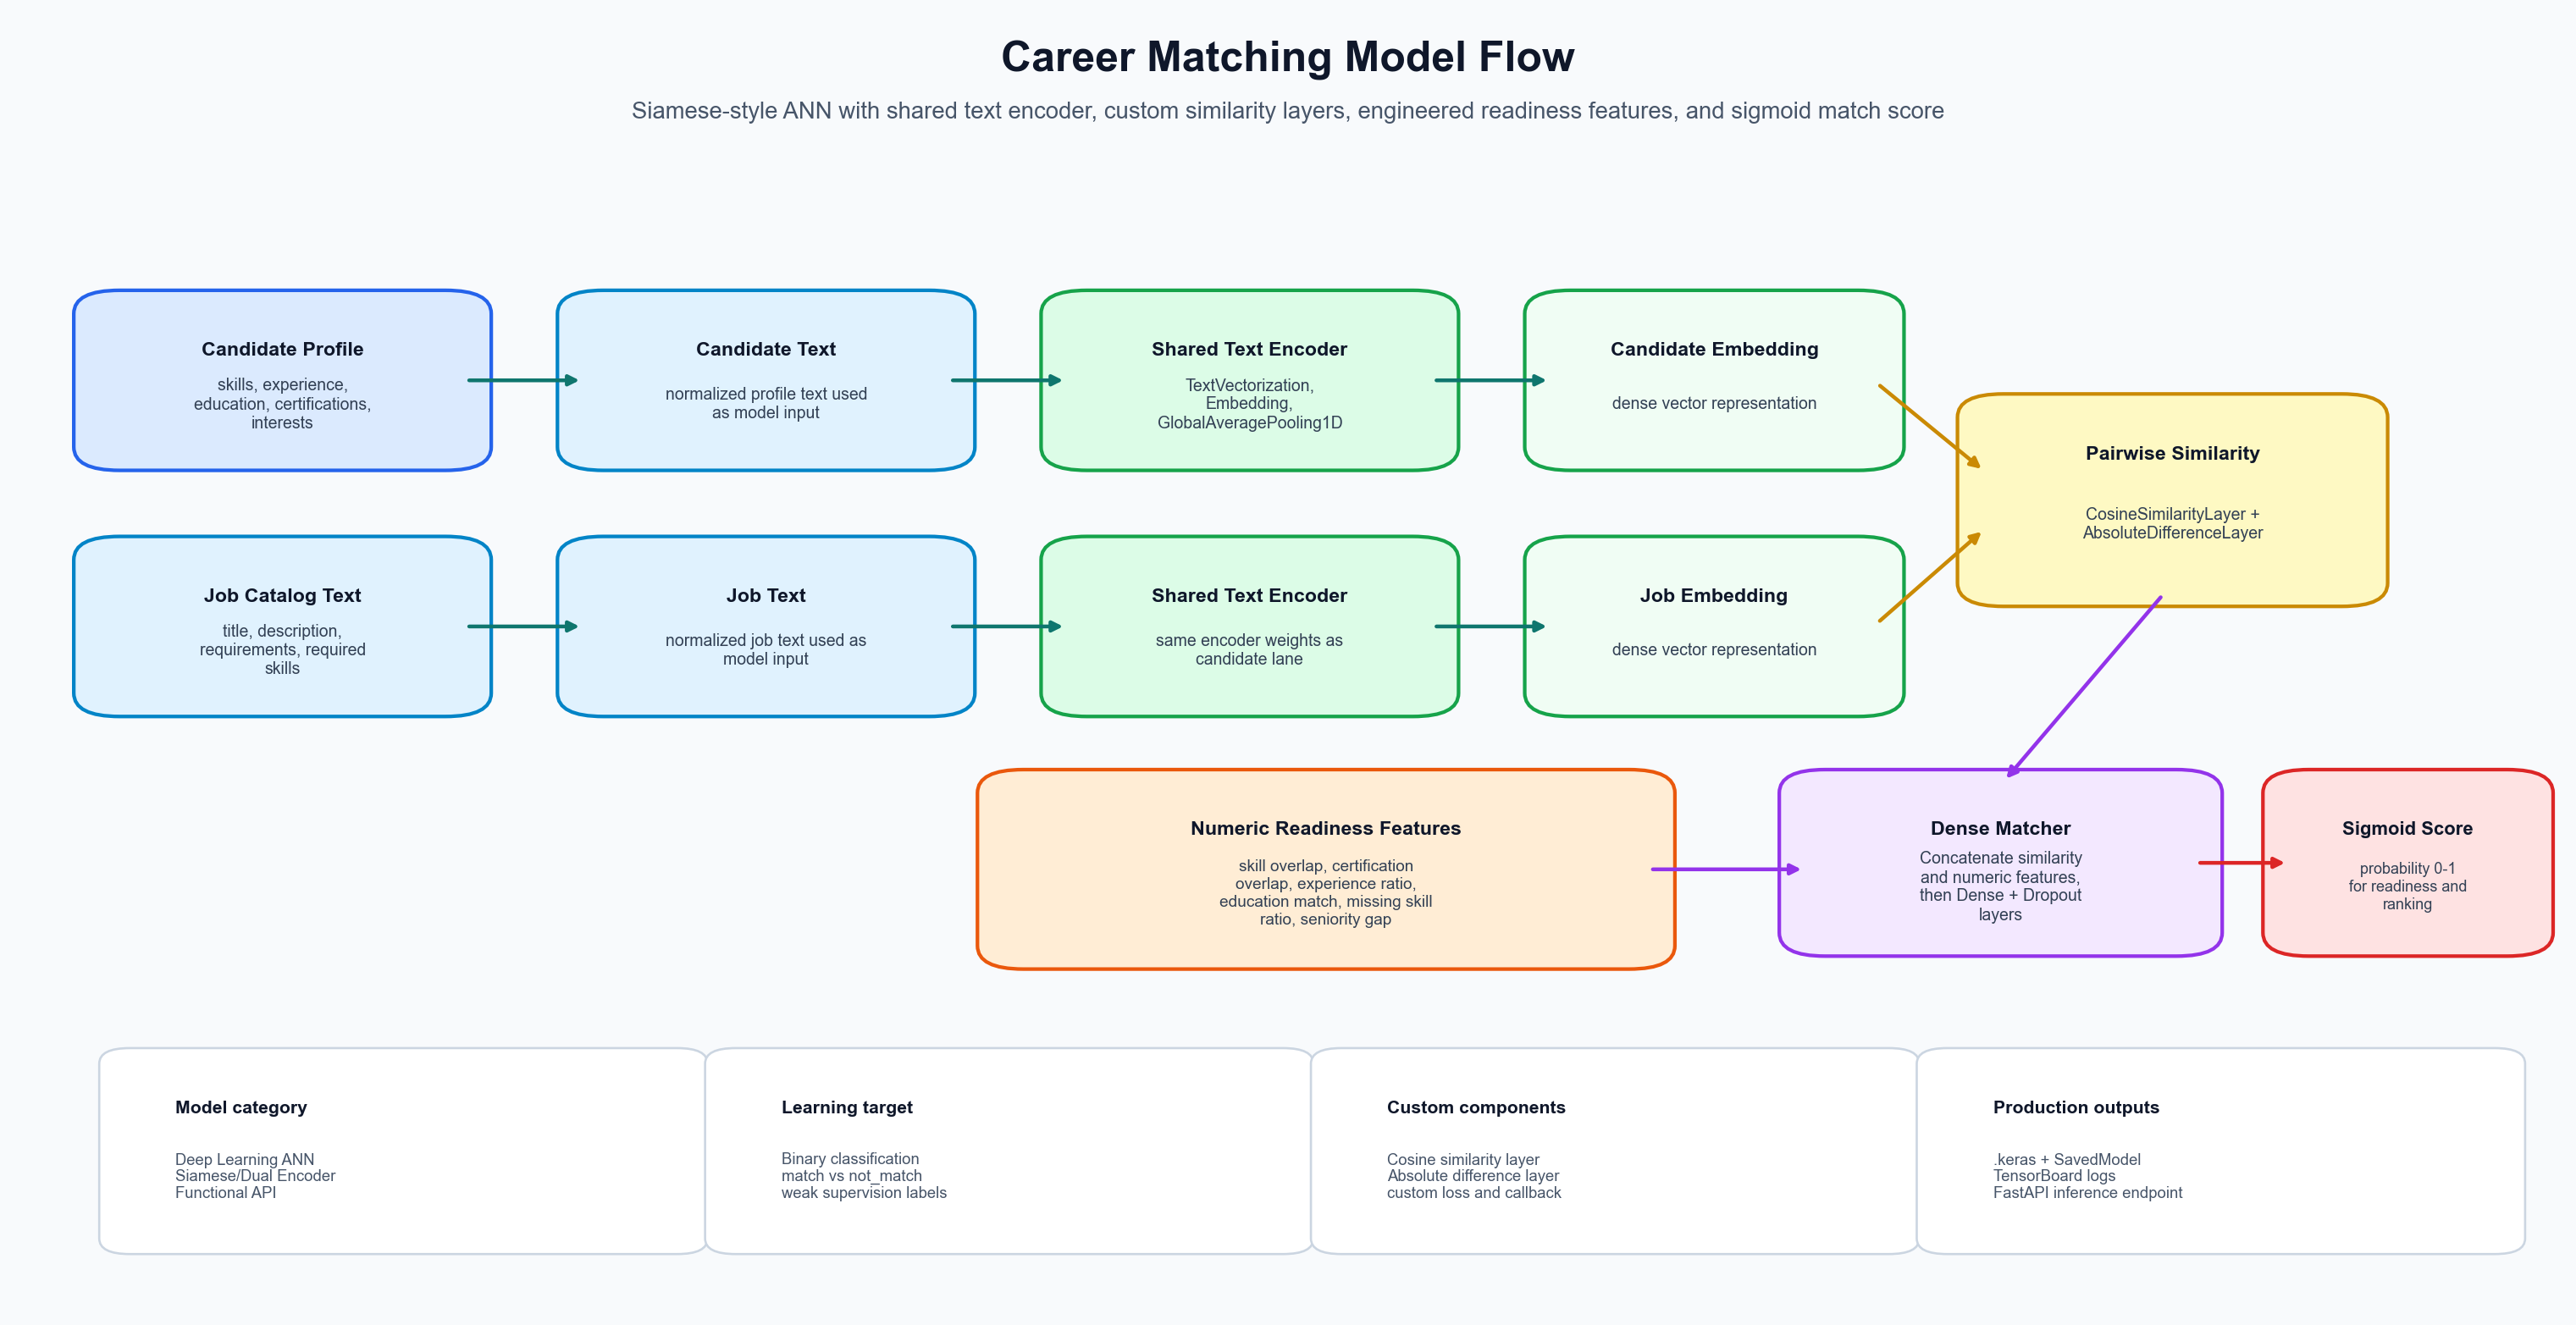

Diagram disimpan di: C:\DBS Foundation\CakapKarier AI\AIEngine\models\registry\career-match\v1\career_matching_model_flow.png


In [30]:
from pathlib import Path
from IPython.display import Image as IPImage, display as ipy_display
from matplotlib.patches import FancyBboxPatch


if 'show_figure' not in globals():
    def show_figure(fig, output_path=None, width=None, dpi=180):
        if output_path is not None:
            output_path = Path(output_path)
            output_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
            ipy_display(IPImage(filename=str(output_path), width=width))
        else:
            ipy_display(fig)
        plt.close(fig)

fig, ax = plt.subplots(figsize=(17, 8.8))
ax.set_facecolor('#f8fafc')
fig.patch.set_facecolor('#f8fafc')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.text(
    0.5,
    0.965,
    'Career Matching Model Flow',
    ha='center',
    va='center',
    fontsize=20,
    fontweight='bold',
    color='#0f172a',
)
ax.text(
    0.5,
    0.925,
    'Siamese-style ANN with shared text encoder, custom similarity layers, engineered readiness features, and sigmoid match score',
    ha='center',
    va='center',
    fontsize=11,
    color='#475569',
)


def add_box(x, y, w, h, title, subtitle, face, edge, title_size=9.3, body_size=7.8, wrap_width=28):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle='round,pad=0.012,rounding_size=0.018',
        facecolor=face,
        edgecolor=edge,
        linewidth=1.7,
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h - 0.034,
        title,
        ha='center',
        va='center',
        fontsize=title_size,
        fontweight='bold',
        color='#0f172a',
    )
    ax.text(
        x + w / 2,
        y + h / 2 - 0.018,
        '\n'.join(wrap(subtitle, wrap_width)),
        ha='center',
        va='center',
        fontsize=body_size,
        color='#334155',
        linespacing=1.22,
    )


def arrow(start, end, color='#0f766e', lw=1.8):
    ax.annotate(
        '',
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle='-|>', lw=lw, color=color, shrinkA=4, shrinkB=4),
    )

# Main two-lane model flow.
top_y = 0.66
bottom_y = 0.47
lane_h = 0.115
lane_w = 0.14

add_box(0.035, top_y, lane_w, lane_h, 'Candidate Profile', 'skills, experience, education, certifications, interests', '#dbeafe', '#2563eb')
add_box(0.225, top_y, lane_w, lane_h, 'Candidate Text', 'normalized profile text used as model input', '#e0f2fe', '#0284c7')
add_box(0.415, top_y, lane_w, lane_h, 'Shared Text Encoder', 'TextVectorization, Embedding, GlobalAveragePooling1D', '#dcfce7', '#16a34a')
add_box(0.605, top_y, 0.125, lane_h, 'Candidate Embedding', 'dense vector representation', '#f0fdf4', '#16a34a')

add_box(0.035, bottom_y, lane_w, lane_h, 'Job Catalog Text', 'title, description, requirements, required skills', '#e0f2fe', '#0284c7')
add_box(0.225, bottom_y, lane_w, lane_h, 'Job Text', 'normalized job text used as model input', '#e0f2fe', '#0284c7')
add_box(0.415, bottom_y, lane_w, lane_h, 'Shared Text Encoder', 'same encoder weights as candidate lane', '#dcfce7', '#16a34a')
add_box(0.605, bottom_y, 0.125, lane_h, 'Job Embedding', 'dense vector representation', '#f0fdf4', '#16a34a')

add_box(0.775, 0.555, 0.145, 0.14, 'Pairwise Similarity', 'CosineSimilarityLayer + AbsoluteDifferenceLayer', '#fef9c3', '#ca8a04', wrap_width=26)
add_box(0.39, 0.275, 0.25, 0.13, 'Numeric Readiness Features', 'skill overlap, certification overlap, experience ratio, education match, missing skill ratio, seniority gap', '#ffedd5', '#ea580c', body_size=7.6, wrap_width=33)
add_box(0.705, 0.285, 0.15, 0.12, 'Dense Matcher', 'Concatenate similarity and numeric features, then Dense + Dropout layers', '#f3e8ff', '#9333ea', wrap_width=25)
add_box(0.895, 0.285, 0.09, 0.12, 'Sigmoid Score', 'probability 0-1 for readiness and ranking', '#fee2e2', '#dc2626', title_size=8.8, body_size=7.2, wrap_width=17)

for y in [top_y, bottom_y]:
    cy = y + lane_h / 2
    arrow((0.175, cy), (0.225, cy))
    arrow((0.365, cy), (0.415, cy))
    arrow((0.555, cy), (0.605, cy))

arrow((0.73, top_y + lane_h / 2), (0.775, 0.645), color='#ca8a04')
arrow((0.73, bottom_y + lane_h / 2), (0.775, 0.605), color='#ca8a04')
arrow((0.845, 0.555), (0.78, 0.405), color='#9333ea')
arrow((0.64, 0.34), (0.705, 0.34), color='#9333ea')
arrow((0.855, 0.345), (0.895, 0.345), color='#dc2626')

# Compact technical summary band.
summary_y = 0.055
summary_h = 0.135
summary_items = [
    ('Model category', 'Deep Learning ANN\nSiamese/Dual Encoder\nFunctional API'),
    ('Learning target', 'Binary classification\nmatch vs not_match\nweak supervision labels'),
    ('Custom components', 'Cosine similarity layer\nAbsolute difference layer\ncustom loss and callback'),
    ('Production outputs', '.keras + SavedModel\nTensorBoard logs\nFastAPI inference endpoint'),
]

for idx, (label, value) in enumerate(summary_items):
    x = 0.045 + idx * 0.238
    note_box = FancyBboxPatch(
        (x, summary_y),
        0.215,
        summary_h,
        boxstyle='round,pad=0.012,rounding_size=0.012',
        facecolor='#ffffff',
        edgecolor='#cbd5e1',
        linewidth=1.05,
    )
    ax.add_patch(note_box)
    ax.text(x + 0.018, summary_y + summary_h - 0.038, label, fontsize=8.5, fontweight='bold', color='#0f172a')
    ax.text(x + 0.018, summary_y + 0.032, value, fontsize=7.4, color='#475569', linespacing=1.12)

plt.tight_layout()
flow_image_path = MODEL_DIR / 'career_matching_model_flow.png'
show_figure(fig, output_path=flow_image_path, width=1100)
print('Diagram disimpan di:', flow_image_path)





In [31]:

import tensorflow as tf

importlib.invalidate_caches()
modeling_module = importlib.import_module('career_match.modeling')
modeling_module = importlib.reload(modeling_module)
custom_objects = {
    'CosineSimilarityLayer': modeling_module.CosineSimilarityLayer,
    'AbsoluteDifferenceLayer': modeling_module.AbsoluteDifferenceLayer,
}

model = tf.keras.models.load_model(
    MODEL_DIR / 'career_match_model.keras',
    custom_objects=custom_objects,
    compile=False,
)

# Tabel arsitektur seperti contoh model.summary() Keras.
model.summary(line_length=120, expand_nested=True)

model_io = pd.DataFrame(
    [
        {
            'kind': 'input',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.inputs
    ]
    + [
        {
            'kind': 'output',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.outputs
    ]
)
display(model_io)


Model: "cakapkarier_career_matcher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ candidate_text (InputLayer)       │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ job_text (InputLayer)             │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ shared_text_encoder (Functional)  │ (None, 64)                   │           788,864 │ candidate_text[0][0],     
│                                   │                              │                   │ job_text[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text (InputLayer)            │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ career_text_vectorizer       │ (None, 160)                  │                 0 │ -                         
│ (TextVectorization)               │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ token_embedding (Embedding)  │ (None, 160, 96)              │           768,000 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ masked_average_pooling       │ (None, 96)                   │                 0 │ -                         
│ (GlobalAveragePooling1D)          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_layer_norm              │ (None, 96)                   │               192 │ -                         
│ (LayerNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dense_1 (Dense)         │ (None, 128)                  │            12,416 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dropout (Dropout)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_embedding (Dense)       │ (None, 64)                   │             8,256 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_abs_diff                │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│ (AbsoluteDifferenceLayer)         │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_product (Multiply)      │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│                                   │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼───────────────────

 Total params: 844,865 (3.22 MB)

 Trainable params: 844,545 (3.22 MB)

 Non-trainable params: 320 (1.25 KB)

,kind,name,shape,dtype
0,input,candidate_text,"(None,)",string
1,input,job_text,"(None,)",string
2,input,numeric_features,"(None, 7)",float32
3,output,keras_tensor_149,"(None, 1)",float32


## 6. Training, Evaluation, dan Export

Bagian ini menjalankan eksperimen training model dan menyimpan artefak final yang siap dipakai oleh service inference. Secara default, notebook tidak menjalankan ulang training jika artefak model sudah tersedia. Untuk retraining, ubah `RUN_TRAINING=True` pada cell setup.

Training dilakukan dengan pendekatan yang memenuhi checklist AI Engineer:

- **TensorFlow Functional API** digunakan untuk membangun model multi-input: `candidate_text`, `job_text`, dan `numeric_features`.
- **Custom training loop** dibuat menggunakan `tf.GradientTape`, sehingga proses forward pass, loss calculation, gradient calculation, dan optimizer step dikontrol secara eksplisit.
- **Custom loss function** `CareerMatchLoss` digunakan untuk mengoptimalkan binary career matching.
- **Custom callback** `QualityThresholdCallback` memantau apakah performa model sudah melewati target minimum akurasi dan MAE.
- **TensorBoard logging** menyimpan metrik training dan validation per epoch.

Evaluasi dilakukan pada validation set dan test set untuk melihat apakah model stabil setelah training. Metrik utama yang dipakai:

- **Binary accuracy**: mengukur persentase prediksi `match` dan `not_match` yang benar.
- **MAE**: mengukur rata-rata selisih probabilitas prediksi terhadap label aktual.
- **Loss**: mengukur kualitas optimisasi model selama training.
- **Classification report**: melihat precision, recall, dan f1-score per kelas.
- **Confusion matrix**: melihat jumlah prediksi benar dan salah untuk kelas `match` dan `not_match`.

Setelah training selesai, model diekspor ke format `.keras` dan SavedModel agar dapat digunakan di environment produksi atau dilayani melalui FastAPI.


In [32]:

from argparse import Namespace

importlib.invalidate_caches()
train_module = importlib.import_module('pipelines.train_model')
train_module = importlib.reload(train_module)

if RUN_TRAINING or not (MODEL_DIR / 'career_match_model.keras').exists():
    train_args = Namespace(
        processed_dir=PROCESSED_DIR,
        model_dir=MODEL_DIR,
        epochs=20,
        min_epochs=5,
        batch_size=64,
        learning_rate=0.0015,
        max_tokens=8000,
        sequence_length=160,
        embedding_dim=96,
        dropout=0.18,
        seed=42,
        min_accuracy=0.85,
        max_mae=0.02,
        skip_threshold_check=False,
    )
    training_metadata = train_module.run_training(train_args)
else:
    training_metadata = json.loads((MODEL_DIR / 'metadata.json').read_text(encoding='utf-8'))
    print('Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.')
    print('Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.')

training_metadata['metrics']


Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.
Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.


{'train': {'loss': 0.00410580774769187,
  'binary_accuracy': 0.9971952438354492,
  'mae': 0.013333464972674847},
 'validation': {'loss': 0.002706635743379593,
  'binary_accuracy': 0.9969879388809204,
  'mae': 0.012775727547705173},
 'test': {'loss': 0.00378962024115026,
  'binary_accuracy': 0.9989959597587585,
  'mae': 0.01200424786657095},
 'thresholds': {'min_accuracy': 0.85, 'max_mae': 0.02},
 'threshold_callback_reached_epoch': 6,
 'training_time': {'epochs_ran': 6,
  'total_epoch_seconds': 58.02,
  'mean_epoch_seconds': 9.67,
  'last_epoch_seconds': 10.505}}

In [33]:
metrics = json.loads((MODEL_DIR / 'metrics.json').read_text(encoding='utf-8'))
metrics_table = pd.DataFrame(
    [
        {'split': split, **metrics[split]}
        for split in ['train', 'validation', 'test']
    ]
)
display(metrics_table)

test_accuracy = metrics['test']['binary_accuracy']
test_mae = metrics['test']['mae']
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print('Target accuracy >= 0.85:', test_accuracy >= 0.85)
print('Target MAE <= 0.02:', test_mae <= 0.02)

,split,loss,binary_accuracy,mae
0,train,0.004106,0.997195,0.013333
1,validation,0.002707,0.996988,0.012776
2,test,0.003790,0.998996,0.012004


Test accuracy: 0.9990
Test MAE: 0.0120
Target accuracy >= 0.85: True
Target MAE <= 0.02: True


## Classification Report dan Confusion Matrix

Evaluasi berikut memakai test set. Karena model ini adalah binary career matching, kelasnya adalah `not_match` dan `match`.

Cara membaca metrik:

- **Precision** menunjukkan seberapa banyak prediksi pada suatu kelas yang benar. Precision tinggi pada kelas `match` berarti model jarang salah menyatakan kandidat cocok.
- **Recall** menunjukkan seberapa banyak data aktual pada suatu kelas yang berhasil ditemukan. Recall tinggi pada kelas `match` berarti model mampu menangkap sebagian besar kandidat yang seharusnya cocok.
- **F1-score** adalah rata-rata harmonis precision dan recall, sehingga cocok dipakai ketika ingin melihat keseimbangan performa.
- **Support** menunjukkan jumlah data test pada masing-masing kelas.
- **Accuracy** menunjukkan rasio prediksi benar dari seluruh data test.

Confusion matrix digunakan sebagai visual pendukung untuk melihat jumlah prediksi benar dan salah. Nilai diagonal menunjukkan prediksi benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi.

Catatan penting: performa tinggi pada MVP ini perlu dibaca bersama konteks weak supervision. Artinya, model sangat baik pada pola label yang dibangun dari rule-based training data, tetapi tetap perlu divalidasi lagi menggunakan data pengguna nyata untuk deployment jangka panjang.


              precision    recall  f1-score   support

   not_match       1.00      1.00      1.00       664
       match       1.00      1.00      1.00       332

    accuracy                           1.00       996
   macro avg       1.00      1.00      1.00       996
weighted avg       1.00      1.00      1.00       996



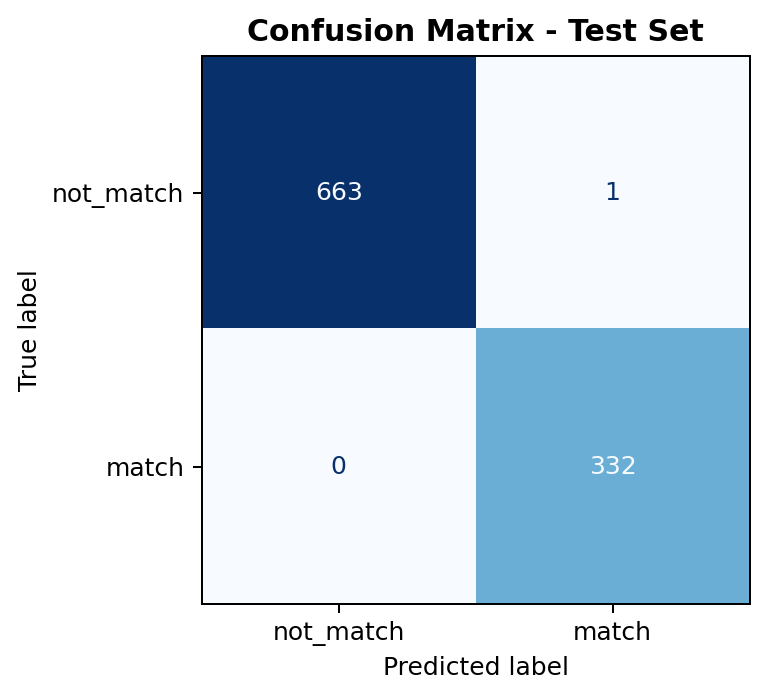

In [34]:
classification_report_txt = MODEL_DIR / 'classification_report.txt'
classification_report_csv = MODEL_DIR / 'classification_report.csv'
confusion_matrix_image = MODEL_DIR / 'confusion_matrix.png'

if classification_report_txt.exists():
    print(classification_report_txt.read_text(encoding='utf-8'))
elif classification_report_csv.exists():
    report_df = pd.read_csv(classification_report_csv)
    display(report_df.round(4))
else:
    print('classification_report.txt belum tersedia. Jalankan training terlebih dahulu.')

if confusion_matrix_image.exists():
    ipy_display(IPImage(filename=str(confusion_matrix_image), width=380))
else:
    print('confusion_matrix.png belum tersedia.')



,epoch,epoch_duration_seconds,epoch_duration_minutes,loss,binary_accuracy,mae,val_loss,val_binary_accuracy,val_mae,val_accuracy_target_met,val_mae_target_met
0,1,9.74492,0.16242,0.01847,0.98080,0.06818,0.08757,0.99699,0.33545,True,False
1,2,9.52208,0.15870,0.00434,0.99720,0.02389,0.03449,0.99598,0.22279,True,False
2,3,9.39219,0.15654,0.00418,0.99741,0.01652,0.01368,0.99900,0.13127,True,False
3,4,9.41069,0.15684,0.00474,0.99612,0.01573,0.00644,0.99900,0.07478,True,False
4,5,9.44473,0.15741,0.00357,0.99676,0.01507,0.00595,0.99598,0.02712,True,False
5,6,10.50512,0.17509,0.00411,0.99720,0.01333,0.00271,0.99699,0.01278,True,True


Total waktu epoch training: 58.02 detik (0.97 menit)
Rata-rata waktu per epoch: 9.67 detik


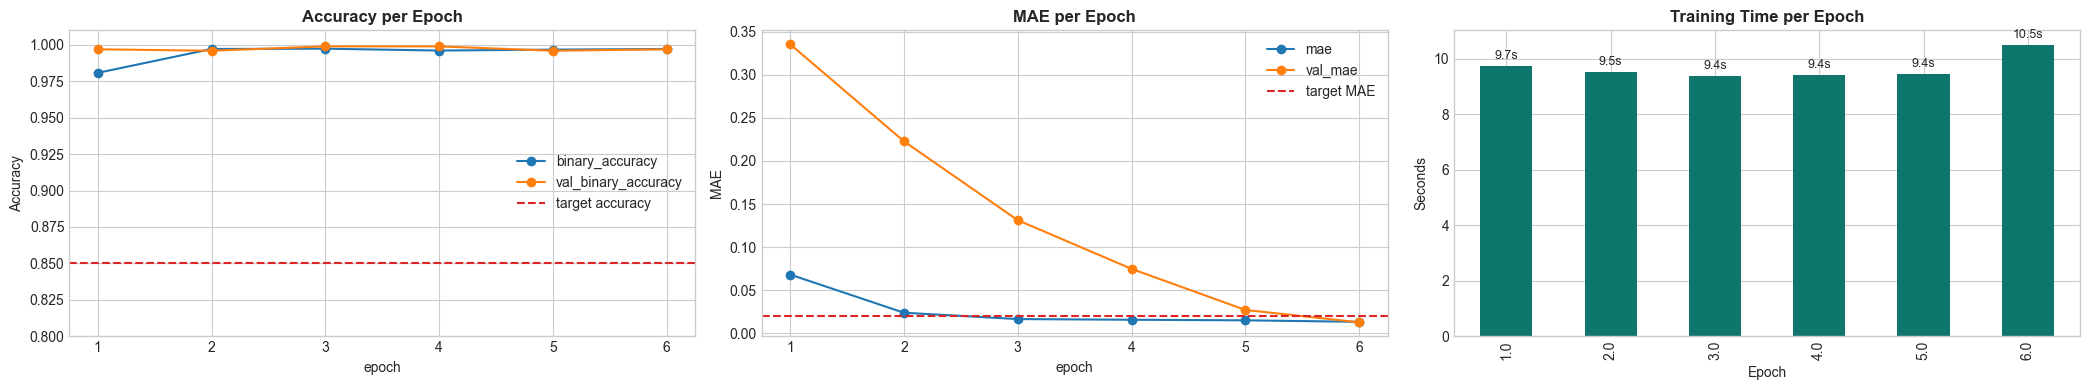

In [35]:
history_path = MODEL_DIR / 'training_history.csv'
history_df = pd.read_csv(history_path)
epoch_log = history_df.copy()
epoch_log['epoch'] = epoch_log['epoch'].astype(int)
epoch_log['val_accuracy_target_met'] = epoch_log['val_binary_accuracy'] >= 0.85
epoch_log['val_mae_target_met'] = epoch_log['val_mae'] <= 0.02

if 'epoch_duration_seconds' in epoch_log.columns:
    epoch_log['epoch_duration_minutes'] = epoch_log['epoch_duration_seconds'] / 60

ordered_columns = [
    'epoch',
    'epoch_duration_seconds',
    'epoch_duration_minutes',
    'loss',
    'binary_accuracy',
    'mae',
    'val_loss',
    'val_binary_accuracy',
    'val_mae',
    'val_accuracy_target_met',
    'val_mae_target_met',
]
ordered_columns = [column for column in ordered_columns if column in epoch_log.columns]
display(epoch_log[ordered_columns].round(5))

if 'epoch_duration_seconds' in history_df.columns:
    total_seconds = history_df['epoch_duration_seconds'].sum()
    mean_seconds = history_df['epoch_duration_seconds'].mean()
    print(f'Total waktu epoch training: {total_seconds:.2f} detik ({total_seconds / 60:.2f} menit)')
    print(f'Rata-rata waktu per epoch: {mean_seconds:.2f} detik')

try:
    figure_count = 3 if 'epoch_duration_seconds' in history_df.columns else 2
    fig, axes = plt.subplots(1, figure_count, figsize=(7 * figure_count, 4))
    if figure_count == 1:
        axes = [axes]

    history_df.plot(x='epoch', y=['binary_accuracy', 'val_binary_accuracy'], marker='o', ax=axes[0])
    axes[0].axhline(0.85, color='#dc2626', linestyle='--', label='target accuracy')
    axes[0].set_title('Accuracy per Epoch')
    axes[0].set_ylim(0.8, 1.01)
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    history_df.plot(x='epoch', y=['mae', 'val_mae'], marker='o', ax=axes[1])
    axes[1].axhline(0.02, color='#dc2626', linestyle='--', label='target MAE')
    axes[1].set_title('MAE per Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    if 'epoch_duration_seconds' in history_df.columns:
        history_df.plot(x='epoch', y='epoch_duration_seconds', kind='bar', color='#0f766e', ax=axes[2], legend=False)
        axes[2].set_title('Training Time per Epoch')
        axes[2].set_ylabel('Seconds')
        axes[2].set_xlabel('Epoch')
        for container in axes[2].containers:
            axes[2].bar_label(container, fmt='%.1fs', padding=3, fontsize=9)

    plt.tight_layout()
    show_figure(fig)
except Exception as exc:
    print('Plot dilewati:', exc)



## 7. Exported Artifacts

Bagian ini menampilkan file hasil training dan evaluasi yang disimpan di model registry. Artefak ini penting karena menjadi bukti bahwa model tidak hanya dilatih di notebook, tetapi juga sudah siap dipakai ulang oleh service inference.

Artefak utama:

- **`career_match_model.keras`**: model TensorFlow/Keras utama dalam format siap load ulang.
- **`saved_model/`**: format TensorFlow SavedModel untuk kebutuhan serving atau deployment lanjutan.
- **`metadata.json`**: informasi versi model, lokasi artefak, konfigurasi training, fitur input, dan metrik akhir.
- **`metrics.json`**: ringkasan metrik train, validation, dan test.
- **`training_history.csv`**: riwayat metrik per epoch, termasuk durasi training tiap epoch.
- **`classification_report.txt`**: laporan precision, recall, f1-score, support, dan accuracy pada test set.
- **`confusion_matrix.png`**: visualisasi kesalahan dan keberhasilan klasifikasi.
- **`jobs_catalog.json`**: katalog lowongan yang dipakai saat inference untuk mencari top matches.
- **`tensorboard/`**: log TensorBoard untuk memantau metrik training dan validation.

Dengan artefak ini, backend tidak perlu menjalankan ulang notebook. Service cukup memuat model, metadata, dan job catalog dari registry.


,artifact,exists,size_mb
0,models\registry\career-match\v1\career_match_m...,True,3.464
1,models\registry\career-match\v1\saved_model,True,6.797
2,models\registry\career-match\v1\jobs_catalog.json,True,5.582
3,models\registry\career-match\v1\metrics.json,True,0.001
4,models\registry\career-match\v1\tensorboard,True,0.005


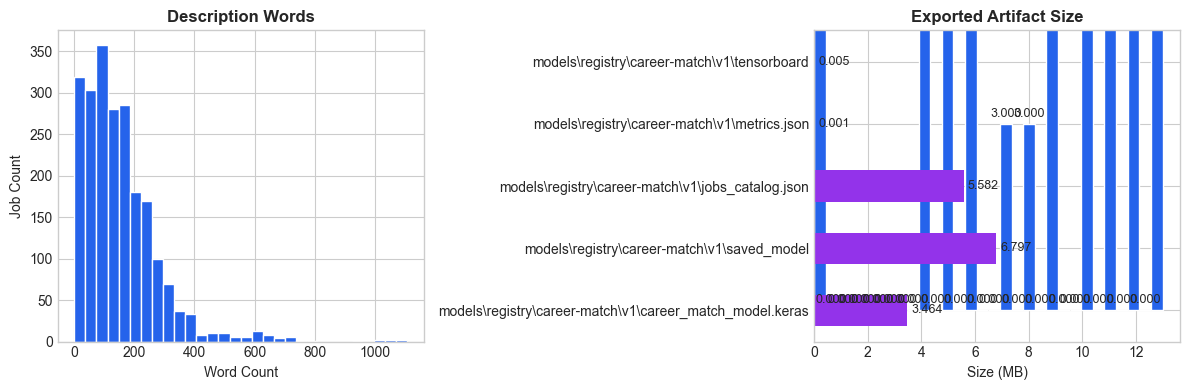

In [36]:
artifact_rows = []
for path in [
    MODEL_DIR / 'career_match_model.keras',
    MODEL_DIR / 'saved_model',
    MODEL_DIR / 'jobs_catalog.json',
    MODEL_DIR / 'metrics.json',
    MODEL_DIR / 'tensorboard',
]:
    if path.is_file():
        size_mb = path.stat().st_size / (1024 * 1024)
    elif path.is_dir():
        size_mb = sum(item.stat().st_size for item in path.rglob('*') if item.is_file()) / (1024 * 1024)
    else:
        size_mb = 0
    artifact_rows.append({'artifact': str(path.relative_to(AIENGINE_ROOT)), 'exists': path.exists(), 'size_mb': round(size_mb, 3)})

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

ax = artifact_df.set_index('artifact')['size_mb'].plot(kind='barh', color='#9333ea')
ax.set_title('Exported Artifact Size')
ax.set_xlabel('Size (MB)')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
show_figure(ax.figure)


## 8. Inference Demo

Bagian ini menunjukkan simulasi penggunaan model setelah training selesai. Tujuannya adalah membuktikan bahwa model dapat menerima profil kandidat dan menghasilkan rekomendasi yang bisa dipakai oleh aplikasi web.

Alur inference:

1. User mengirim profil, seperti skill, pengalaman, pendidikan, sertifikasi, target role, dan lokasi preferensi.
2. Service membentuk `candidate_text` dan fitur numerik kandidat.
3. Kandidat dibandingkan dengan lowongan di `jobs_catalog.json`.
4. Model menghasilkan `match_score` untuk setiap pasangan kandidat-lowongan.
5. Service mengurutkan lowongan berdasarkan score tertinggi.
6. Output dikemas menjadi response yang mudah dipakai oleh frontend.

Output yang dihasilkan:

- **Predicted role**: role atau lowongan paling relevan berdasarkan ranking model.
- **Readiness score**: skor kesiapan kandidat dalam skala 0 sampai 100.
- **Readiness status**: kategori kesiapan seperti `Siap`, `Cukup Siap`, atau `Perlu Ditingkatkan`.
- **Top matches**: daftar lowongan paling cocok.
- **Matched skills**: skill kandidat yang sudah sesuai dengan kebutuhan lowongan.
- **Skill gap**: skill yang masih perlu ditingkatkan.
- **Roadmap**: rekomendasi tahapan belajar.
- **Recommendations**: saran praktis untuk meningkatkan kesiapan karier.

Demo ini penting untuk menjembatani model AI dengan kebutuhan tim fullstack, karena response inference sudah menyerupai format yang dibutuhkan oleh aplikasi.


In [37]:

importlib.invalidate_caches()
inference_module = importlib.import_module('career_match.inference')
inference_module = importlib.reload(inference_module)
CareerMatchService = inference_module.CareerMatchService

service = CareerMatchService(MODEL_DIR)
prediction = service.predict(
    skills=['Python', 'SQL', 'Machine Learning', 'Data Analysis', 'TensorFlow'],
    experience_years=2,
    education_level='bachelor',
    certifications=['TensorFlow Developer'],
    preferred_location='Jakarta',
    top_k=5,
)
prediction


{'predicted_role': 'Tenaga Pengajar It',
 'target_role': None,
 'role_family': 'design-content',
 'readiness_score': 79.21,
 'readiness_status': 'Cukup Siap',
 'match_confidence': 0.7921,
 'numeric_features': ['skill_overlap',
  'certification_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'top_matches': [{'job_id': 'glints-1776679414-790',
   'job_title': 'Tenaga Pengajar It',
   'company': 'Digikidz',
   'location': 'Kab. Tangerang, Banten',
   'job_detail': 'https://glints.com/id/en/opportunities/jobs/tenaga-pengajar-it/a308572e-c7e6-4e49-837f-24ee55a60d5c?utm_referrer=explore&traceInfo=17cddaadb4bac2102035b5df6f5fb67e',
   'role_family': 'design-content',
   'work_mode': 'unknown',
   'required_experience_years': 1.0,
   'required_education': 'diploma',
   'match_score': 0.7921,
   'readiness_percentage': 79.21,
   'target_alignment': 0,
   'matched_skills': ['machine learning', 'python'],
   'missing_skills

,job_id,job_title,company,location,job_detail,role_family,work_mode,required_experience_years,required_education,match_score,readiness_percentage,target_alignment,matched_skills,missing_skills
0,glints-1776679414-790,Tenaga Pengajar It,Digikidz,"Kab. Tangerang, Banten",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.7921,79.21,0,"[machine learning, python]",[pytorch]
1,glints-1778509661-793,Tenaga Pengajar It,Digikidz,"Kab. Tangerang, Banten",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.7825,78.25,0,"[python, machine learning]",[pytorch]
2,glints-1778509687-802,Tenaga Pengajar It,Digikidz,"Medan, Sumatera Utara",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.7825,78.25,0,"[python, machine learning]",[pytorch]
3,linkedin-linkedin-2013,Data Engineer,Vlink Inc,"Jakarta, Indonesia",,data-ai,unknown,0.0,bachelor,0.3667,36.67,0,"[python, sql]",[etl]
4,glints-1776678050-440,Data Pipeline,Xnine Indonesia,"Jakarta Selatan, Dki Jakarta",https://glints.com/id/en/opportunities/jobs/da...,data-ai,onsite,1.0,bachelor,0.3600,36.00,0,"[sql, data analysis]","[elasticsearch, grafana, agile]"


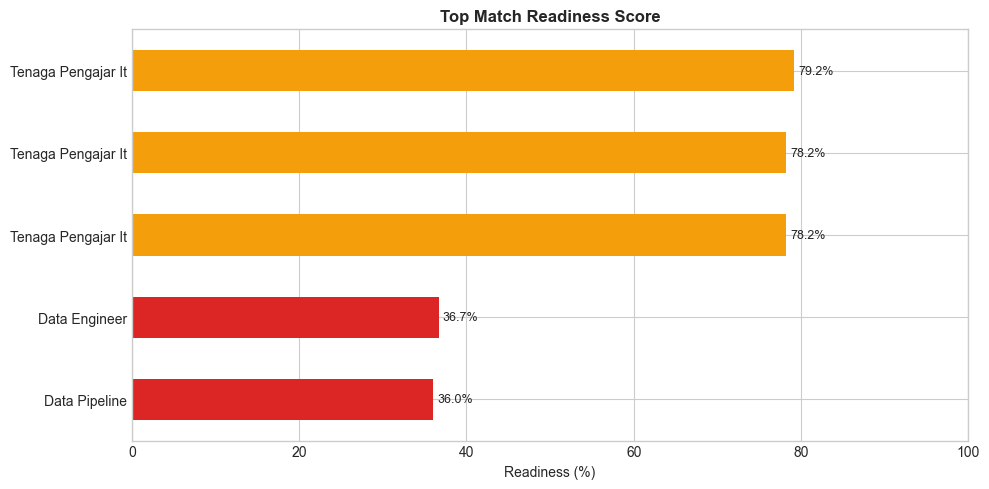

Predicted role: Tenaga Pengajar It
Readiness score: 79.21
Skill gap: ['pytorch']
Recommendations:
- Bangun bukti portofolio untuk pytorch lewat mini project, latihan studi kasus, dan sertifikasi dasar.


In [38]:
top_matches_df = pd.DataFrame(prediction['top_matches'])
display(top_matches_df)

plot_df = top_matches_df.sort_values('readiness_percentage')
colors = ['#16a34a' if value >= 85 else '#f59e0b' if value >= 70 else '#dc2626' for value in plot_df['readiness_percentage']]
ax = plot_df.plot(kind='barh', x='job_title', y='readiness_percentage', legend=False, color=colors, figsize=(10, 5))
ax.set_title('Top Match Readiness Score')
ax.set_xlabel('Readiness (%)')
ax.set_ylabel('')
ax.set_xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
show_figure(ax.figure)

print('Predicted role:', prediction['predicted_role'])
print('Readiness score:', prediction['readiness_score'])
print('Skill gap:', prediction['skill_gap'])
print('Recommendations:')
for item in prediction['recommendations']:
    print('-', item)


## 9. REST API Contract

FastAPI service disediakan agar model dapat dipakai oleh aplikasi tanpa menjalankan notebook. Service memuat model dari registry, membaca job catalog, melakukan preprocessing input user, menjalankan inference, lalu mengembalikan response dalam format JSON.

Jalankan dari folder `AIEngine`:

```bash
uvicorn career_match.app:app --app-dir services/career-match/src --host 127.0.0.1 --port 8001
```

Endpoint utama:

- **`GET /health`**: mengecek apakah service dan model tersedia.
- **`GET /genai/health`**: mengecek status provider GenAI optional, disini memakai Ollama.
- **`POST /predict`**: endpoint inference utama dengan schema AI Engine.
- **`POST /predict/web`**: endpoint adapter untuk integrasi dengan form dari WebApplication.

Input penting yang perlu disiapkan oleh frontend:

- **Skill**: daftar skill yang dikuasai kandidat.
- **Pengalaman**: jumlah tahun pengalaman atau teks pengalaman.
- **Sertifikasi**: daftar sertifikasi kandidat, boleh kosong jika belum ada.
- **Pendidikan**: pendidikan terakhir kandidat.
- **Target role**: role yang ingin dituju, misalnya Front-End Developer, Data Scientist, atau AI Engineer.

Response utama yang dikembalikan service:

- `predicted_role`
- `readiness_score`
- `readiness_status`
- `match_confidence`
- `top_matches`
- `mastered_skills`
- `skill_gap`
- `skill_gap_analysis`
- `roadmap`
- `recommendations`
- `tips`
- `ai_summary`

Kontrak lengkap tersedia di `AIEngine/shared/schemas/career_match_contract.json`. File ini menjadi acuan bersama antara AI Engineer dan tim fullstack agar integrasi tidak bergantung pada asumsi informal.


In [39]:
contract_path = AIENGINE_ROOT / 'shared' / 'schemas' / 'career_match_contract.json'
contract = json.loads(contract_path.read_text(encoding='utf-8'))
contract

{'service': 'career-match',
 'version': '1.2.0',
 'endpoints': {'health': 'GET /health',
  'genai_health': 'GET /genai/health',
  'predict': 'POST /predict',
  'predict_web': 'POST /predict/web'},
 'request': {'skills': {'type': 'array<string>|string',
   'required': True,
   'description': 'Daftar skill kandidat. Untuk /predict disarankan array; /predict/web boleh string dipisah koma.'},
  'experience_years': {'type': 'number',
   'required': 'true for /predict, optional for /predict/web',
   'min': 0,
   'max': 60},
  'education_level': {'type': 'string|integer',
   'required': False,
   'examples': ['sma', 'd3', 's1', 'diploma', 'bachelor', 'master', 3]},
  'certifications': {'type': 'array<string>|string',
   'required': 'true for /predict, optional for /predict/web',
   'description': 'Daftar sertifikasi kandidat. Kirim array kosong jika kandidat belum memiliki sertifikasi.'},
  'interests': {'type': 'array<string>|string|null',
   'required': False,
   'description': 'Minat dan b

## 10. TensorBoard

TensorBoard digunakan untuk memantau proses training secara visual. Log TensorBoard disimpan di model registry sehingga metrik training tetap tersedia sebagai artefak repository akhir.

Informasi yang bisa dilihat di TensorBoard:

- **Training loss**: apakah model semakin baik meminimalkan error selama training.
- **Validation loss**: apakah performa pada data validasi ikut membaik atau justru memburuk.
- **Binary accuracy**: akurasi model pada data train dan validation per epoch.
- **MAE**: rata-rata error probabilitas prediksi terhadap label.
- **Epoch duration**: waktu yang dibutuhkan setiap epoch.

Jika training dijalankan beberapa kali, TensorBoard dapat menampilkan lebih dari satu event file. Itu normal karena setiap proses training membuat log baru. Untuk demo final, cukup gunakan run terakhir atau kosongkan folder TensorBoard sebelum retraining final.

Jalankan dari folder `AIEngine`:

```bash
tensorboard --logdir models/registry/career-match/v1/tensorboard --port 6006
```

Lalu buka browser ke:

```text
http://localhost:6006
```

Tab yang paling relevan untuk project ini adalah **Scalars**, karena metrik model disimpan sebagai scalar per epoch. Jika TensorBoard menampilkan pesan tidak ada scalar data, pastikan path `--logdir` mengarah ke folder `models/registry/career-match/v1/tensorboard` dari dalam folder `AIEngine`.


,run,file,size_kb,last_modified
0,train,events.out.tfevents.1778658055.ASUS-TUF-A15.46...,1.69,1.778658e+09
1,train,events.out.tfevents.1778680177.ASUS-TUF-A15.56...,1.23,1.778680e+09
2,validation,events.out.tfevents.1778658055.ASUS-TUF-A15.46...,1.29,1.778658e+09
3,validation,events.out.tfevents.1778680177.ASUS-TUF-A15.56...,0.95,1.778680e+09


,file_count,total_size_kb
run,,
train,2,2.92
validation,2,2.24


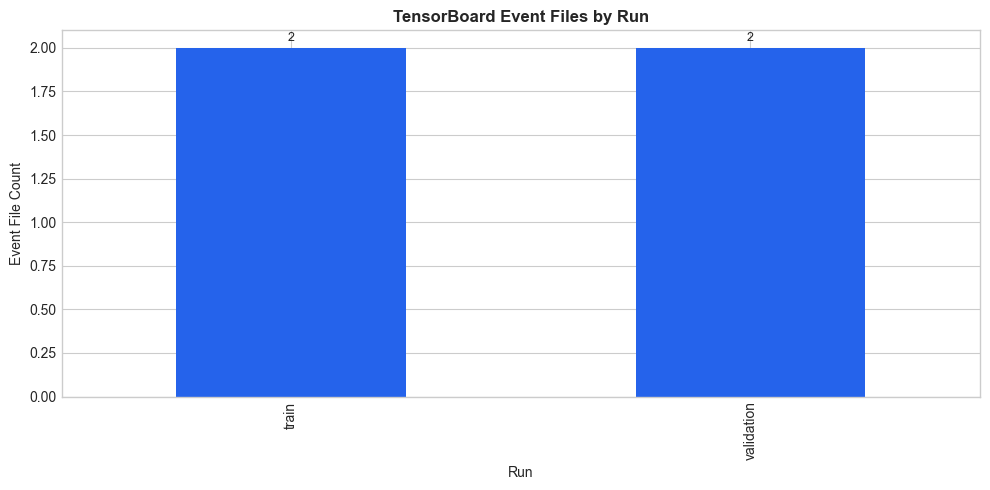

In [40]:
event_files = []
for path in (MODEL_DIR / 'tensorboard').rglob('events.out.tfevents*'):
    event_files.append(
        {
            'run': path.parent.name,
            'file': path.name,
            'size_kb': round(path.stat().st_size / 1024, 2),
            'last_modified': path.stat().st_mtime,
        }
    )

event_df = pd.DataFrame(event_files).sort_values(['run', 'file'])
display(event_df)

if not event_df.empty:
    summary_df = event_df.groupby('run').agg(file_count=('file', 'count'), total_size_kb=('size_kb', 'sum'))
    display(summary_df)
    ax = summary_df['file_count'].plot(kind='bar', color='#2563eb')
    ax.set_title('TensorBoard Event Files by Run')
    ax.set_xlabel('Run')
    ax.set_ylabel('Event File Count')
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    plt.tight_layout()
    show_figure(ax.figure)
